In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

BOTTLE_DIR = '/content/drive/MyDrive/bottle'

# Verify the path exists
if os.path.exists(BOTTLE_DIR):
    print(f"✅ Found dataset at: {BOTTLE_DIR}")
    print("Contents:", os.listdir(BOTTLE_DIR))
else:
    print(f"❌ Error: Could not find path: {BOTTLE_DIR}")
    print("Please check your Google Drive structure and update 'BOTTLE_DIR'.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found dataset at: /content/drive/MyDrive/bottle
Contents: ['readme.txt', 'license.txt', 'ground_truth', 'test', 'train']


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# --- 1. DATASET CLASS ---
class MVTecDriveDataset(Dataset):
    def __init__(self, root_dir, mode='train', transform=None):
        self.transform = transform
        self.mode = mode
        self.image_paths = []

        # Define paths based on MVTec structure
        if mode == 'train':
            # Train on defect-free samples only
            img_dir = os.path.join(root_dir, 'train', 'good')
        else:
            img_dir = os.path.join(root_dir, 'test', 'good')

        if os.path.exists(img_dir):
            self.image_paths = [os.path.join(img_dir, f) for f in os.listdir(img_dir)
                                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        else:
            print(f"Warning: Directory not found: {img_dir}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, 0 # Label 0 (Normal)



In [4]:
# CONFIGURATION & PREPROCESSING
IMG_SIZE = 128
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 20  # Increase this for better results (e.g., 50 or 100)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Load Data
train_dataset = MVTecDriveDataset(BOTTLE_DIR, mode='train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Training on {len(train_dataset)} normal images from Drive...")



Training on 209 normal images from Drive...


In [5]:
# MODEL DEFINITION
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x



In [6]:
#  TRAINING LOOP
model = Autoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

model.train()
loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0
    for img, _ in train_loader:
        img = img.to(DEVICE)

        output = model(img)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    if (epoch+1) % 5 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')



Epoch [5/20], Loss: 0.0313
Epoch [10/20], Loss: 0.0050
Epoch [15/20], Loss: 0.0030
Epoch [20/20], Loss: 0.0026


✅ Model trained and saved as 'bottle_ae_model.pth'


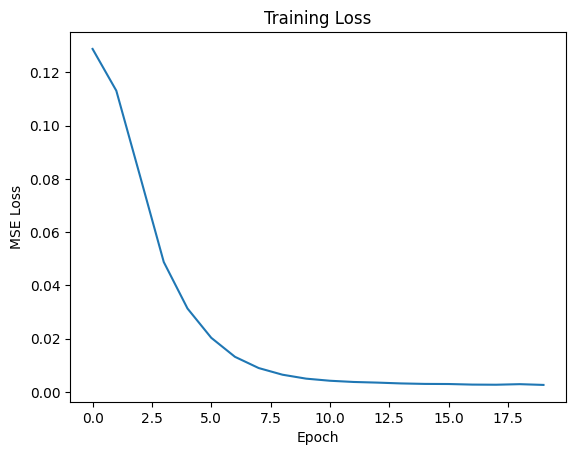

In [7]:
# Save the model
torch.save(model.state_dict(), 'bottle_ae_model.pth')
print(" Model trained and saved as 'bottle_ae_model.pth'")

# Plot Loss
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

📂 Found test categories: ['broken_small', 'good', 'broken_large', 'contamination']
⏳ Running evaluation on all test images... (This might take a moment)
📊 Stats:
   Avg Normal Score:  0.00285
   Avg Anomaly Score: 0.00290
   Suggested Threshold: 0.00288


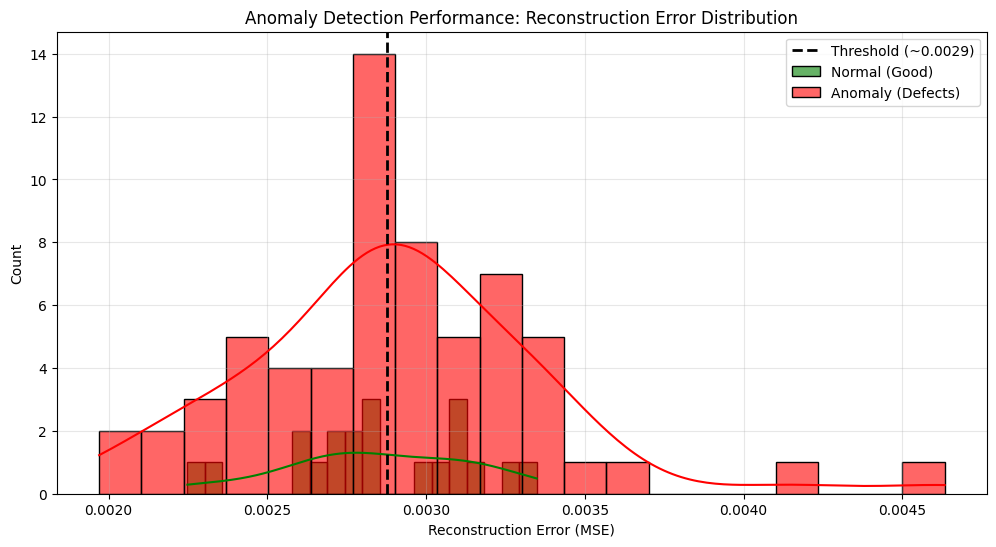

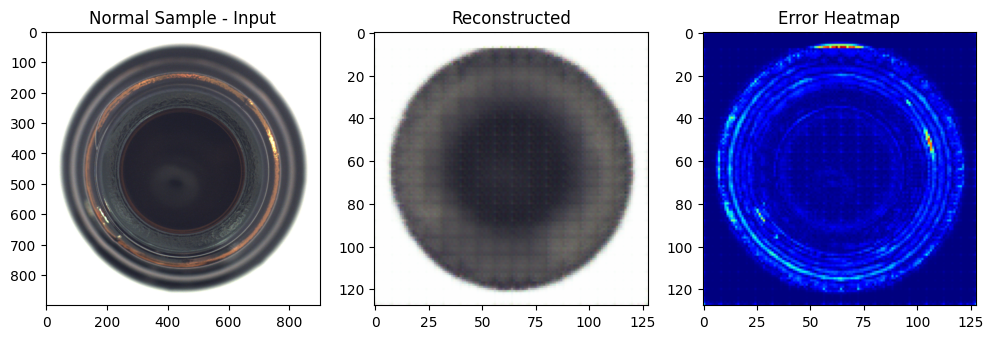

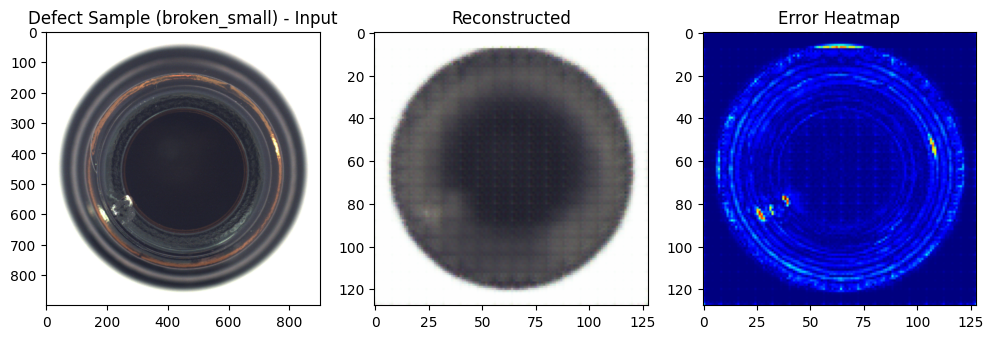

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns


test_root = os.path.join(BOTTLE_DIR, 'test')
subfolders = os.listdir(test_root)

print(f"📂 Found test categories: {subfolders}")

# Lists to store scores
normal_scores = []
anomaly_scores = []

model.eval()
criterion = nn.MSELoss()

print("⏳ Running evaluation on all test images... (This might take a moment)")

with torch.no_grad():
    for folder_name in subfolders:
        folder_path = os.path.join(test_root, folder_name)

        # Skip if it's not a folder
        if not os.path.isdir(folder_path):
            continue

        # Determine if this folder contains "good" or "anomaly" images
        is_anomaly = folder_name != 'good'
        label_str = "Anomaly" if is_anomaly else "Normal"

        # Iterate over images in this folder
        for img_name in os.listdir(folder_path):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            img_path = os.path.join(folder_path, img_name)

            # Load & Preprocess
            img_pil = Image.open(img_path).convert('RGB')
            img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

            # Inference
            reconstructed = model(img_tensor)

            # Calculate MSE Score (Anomaly Score)
            loss = criterion(reconstructed, img_tensor).item()

            if is_anomaly:
                anomaly_scores.append(loss)
            else:
                normal_scores.append(loss)

# VISUALIZATION OF RESULTS
plt.figure(figsize=(12, 6))

# Plot Histograms
sns.histplot(normal_scores, color='green', label='Normal (Good)', kde=True, bins=20, alpha=0.6)
sns.histplot(anomaly_scores, color='red', label='Anomaly (Defects)', kde=True, bins=20, alpha=0.6)

# Calculate a suggested threshold (simple mean between the two peaks)
if normal_scores and anomaly_scores:
    avg_normal = np.mean(normal_scores)
    avg_anomaly = np.mean(anomaly_scores)
    suggested_threshold = (avg_normal + avg_anomaly) / 2

    plt.axvline(suggested_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold (~{suggested_threshold:.4f})')
    print(f"📊 Stats:")
    print(f"   Avg Normal Score:  {avg_normal:.5f}")
    print(f"   Avg Anomaly Score: {avg_anomaly:.5f}")
    print(f"   Suggested Threshold: {suggested_threshold:.5f}")

plt.title("Anomaly Detection Performance: Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Let's visualize one normal and one anomaly to see the difference
def show_sample(img_path, title):
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        recon = model(img_tensor)

    diff = torch.abs(img_tensor - recon)
    error_map = torch.mean(diff, dim=1).squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(img_pil)
    ax[0].set_title(f"{title} - Input")
    ax[1].imshow(recon.squeeze().permute(1, 2, 0).cpu().numpy())
    ax[1].set_title("Reconstructed")
    ax[2].imshow(error_map, cmap='jet')
    ax[2].set_title("Error Heatmap")
    plt.show()

# Pick the first image from 'good' and first from 'broken_large' (if exists)
try:
    good_sample = os.path.join(test_root, 'good', os.listdir(os.path.join(test_root, 'good'))[0])
    show_sample(good_sample, "Normal Sample")

    # Try to find a defect folder
    defect_folder = [f for f in subfolders if f != 'good'][0]
    defect_sample = os.path.join(test_root, defect_folder, os.listdir(os.path.join(test_root, defect_folder))[0])
    show_sample(defect_sample, f"Defect Sample ({defect_folder})")
except Exception as e:
    print(f"Could not display examples: {e}")

✅ Model loaded successfully.
📂 Found Categories: ['broken_small', 'good', 'broken_large', 'contamination']


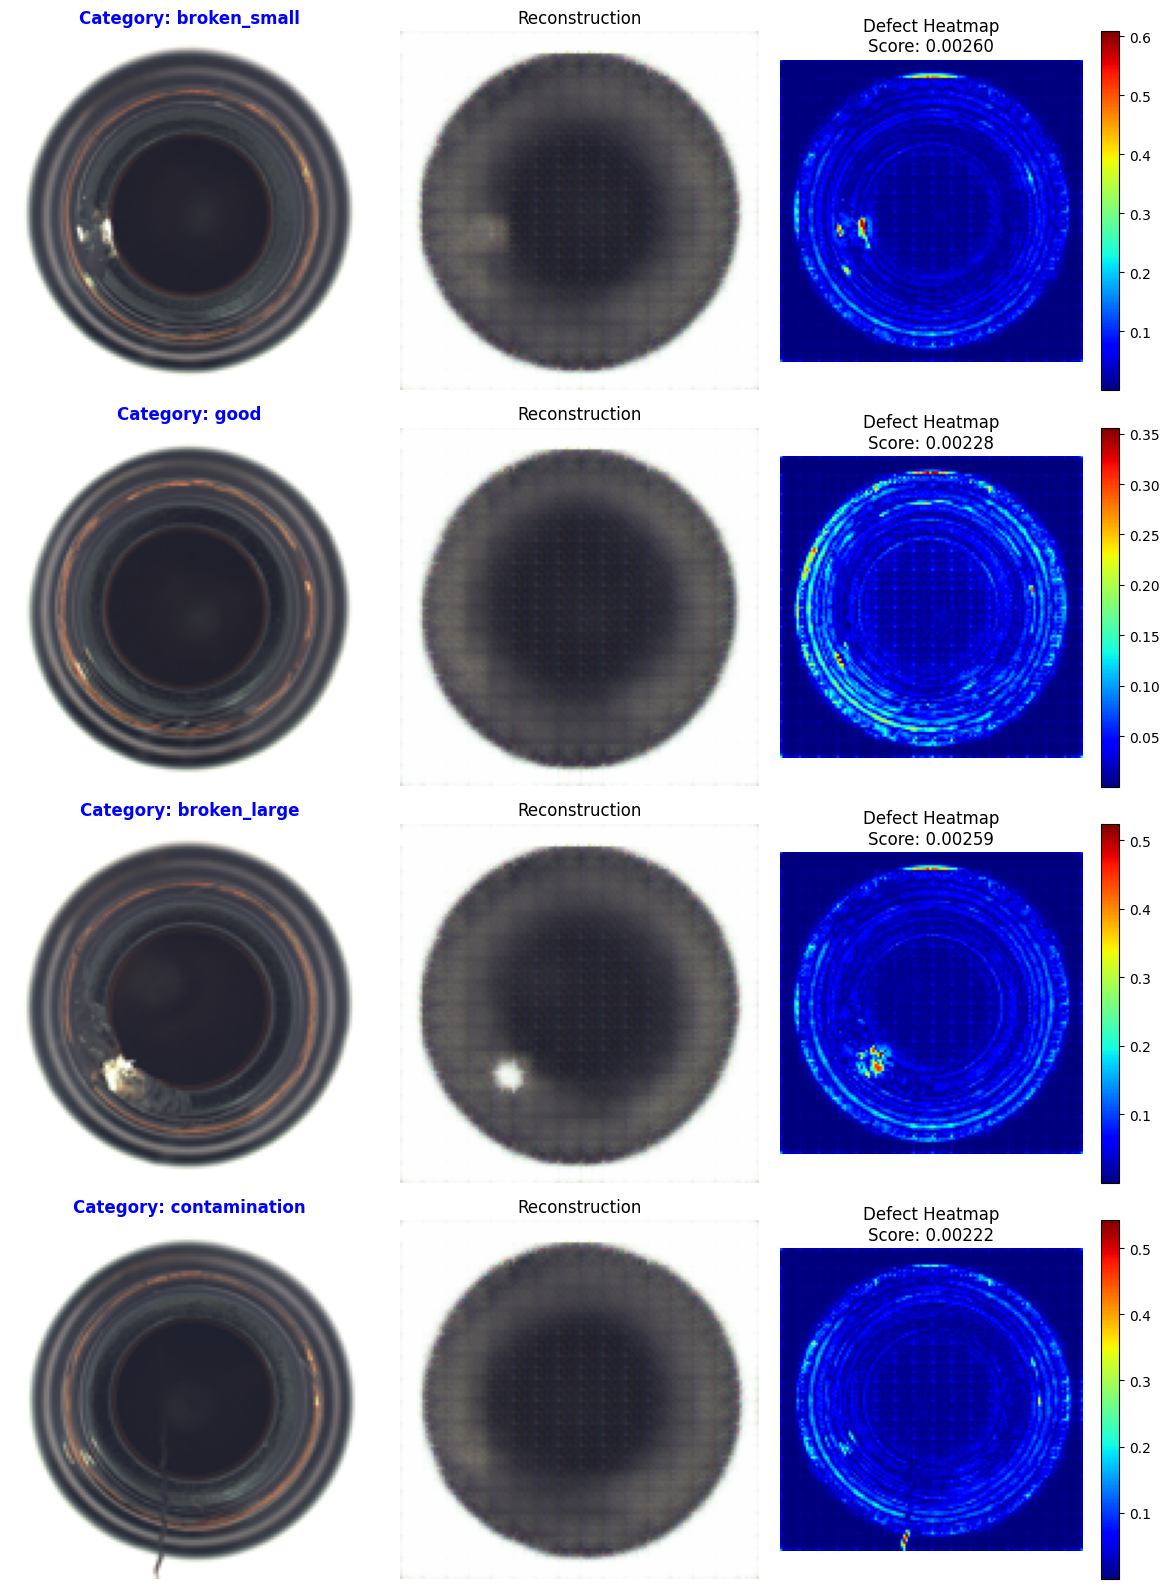

In [18]:
import os
import random
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import numpy as np


BOTTLE_DIR = '/content/drive/MyDrive/bottle/'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128

# Load the Model
model = Autoencoder().to(DEVICE)
try:
    model.load_state_dict(torch.load('bottle_ae_model.pth', map_location=DEVICE))
    print("✅ Model loaded successfully.")
except:
    print("❌ Model file not found. Please train the model first.")

model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# VALIDATION FUNCTION
def test_mvtec_folder():
    test_root = os.path.join(BOTTLE_DIR, 'test')

    # Get all subfolders (good, broken_large, broken_small, contamination)
    subfolders = [f for f in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, f))]

    print(f"📂 Found Categories: {subfolders}")

    # Create a plot row for each category
    fig, axes = plt.subplots(len(subfolders), 3, figsize=(12, 4 * len(subfolders)))

    for i, folder_name in enumerate(subfolders):
        folder_path = os.path.join(test_root, folder_name)
        images = os.listdir(folder_path)

        if len(images) == 0: continue

        # Pick a random image from this category
        img_name = random.choice(images)
        img_path = os.path.join(folder_path, img_name)

        # Inference
        img_pil = Image.open(img_path).convert('RGB')
        img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            recon = model(img_tensor)

        # Calculate Error Heatmap
        diff = torch.abs(img_tensor - recon)
        error_map = torch.mean(diff, dim=1).squeeze().cpu().numpy()
        mse_score = np.mean(error_map**2)

        # --- PLOTTING ---
        # 1. Original
        ax = axes[i] if len(subfolders) > 1 else axes
        ax[0].imshow(img_pil.resize((IMG_SIZE, IMG_SIZE)))
        ax[0].set_title(f"Category: {folder_name}", color='blue', fontweight='bold')
        ax[0].axis('off')

        # 2. Reconstruction
        ax[1].imshow(recon.squeeze().permute(1, 2, 0).cpu().numpy())
        ax[1].set_title("Reconstruction")
        ax[1].axis('off')

        # 3. Heatmap
        im = ax[2].imshow(error_map, cmap='jet')
        ax[2].set_title(f"Defect Heatmap\nScore: {mse_score:.5f}")
        ax[2].axis('off')
        plt.colorbar(im, ax=ax[2])

    plt.tight_layout()
    plt.show()


test_mvtec_folder()

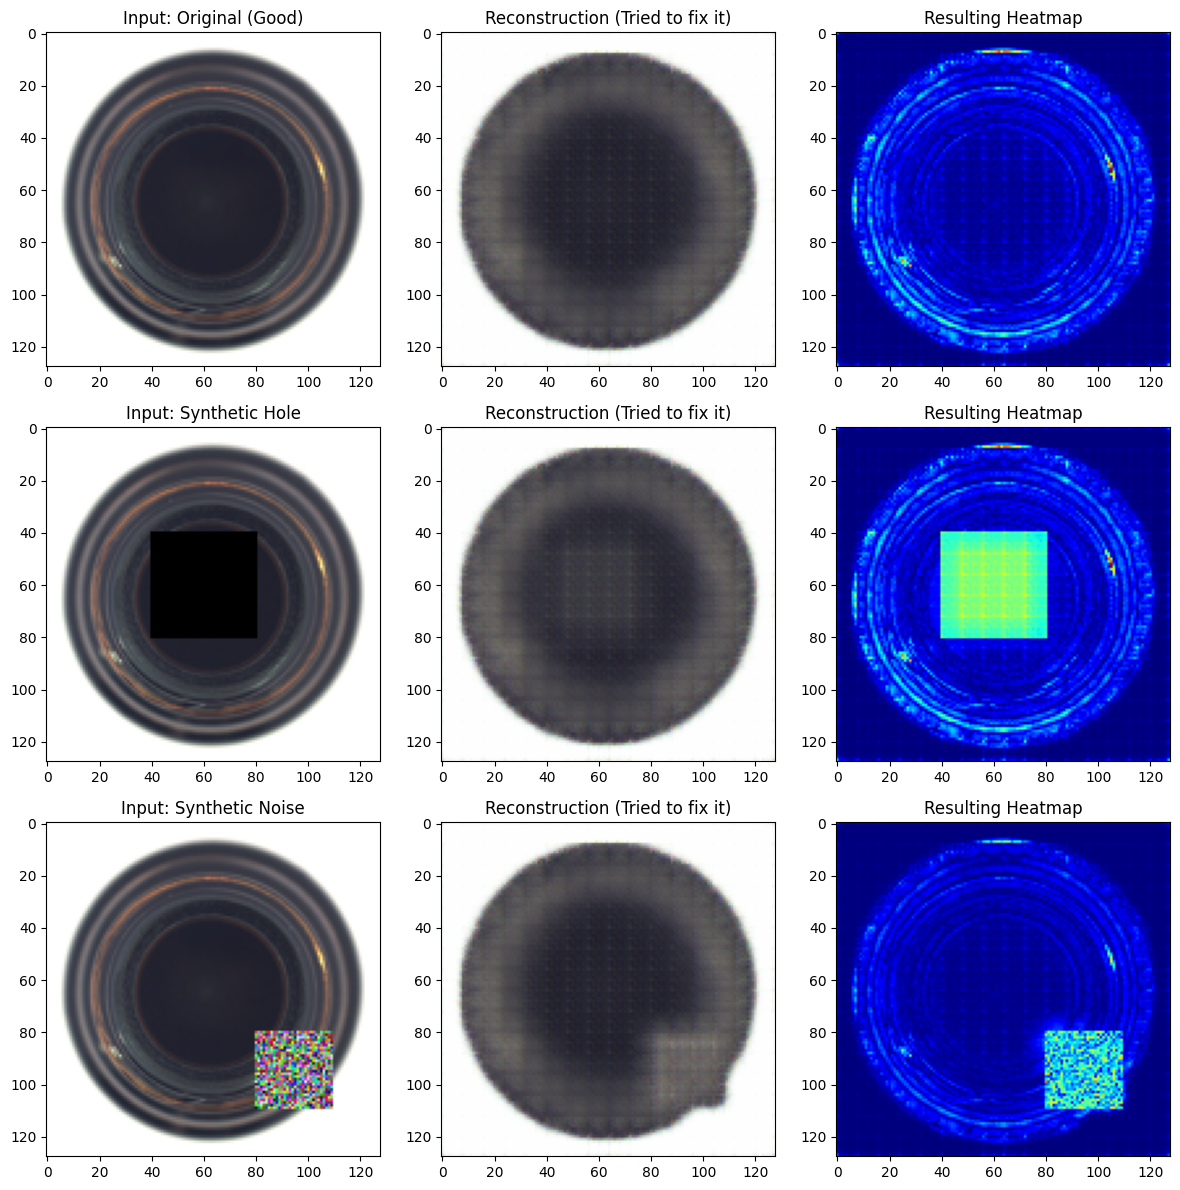

In [19]:
import cv2

def generate_and_test_defect():
    #  Get a GOOD image
    train_good_dir = os.path.join(BOTTLE_DIR, 'train', 'good')
    img_name = random.choice(os.listdir(train_good_dir))
    img_path = os.path.join(train_good_dir, img_name)

    # Load as Numpy array for editing
    original_pil = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_np = np.array(original_pil)

    # CREATE SYNTHETIC DEFECTS

    # Defect A: A big black square (Simulating a missing chunk)
    defective_img = img_np.copy()
    cv2.rectangle(defective_img, (40, 40), (80, 80), (0, 0, 0), -1)

    # Defect B: White Noise (Simulating dust/scratch texture)
    noise_img = img_np.copy()
    noise = np.random.randint(0, 255, (30, 30, 3), dtype='uint8')
    noise_img[80:110, 80:110] = noise # Place noise in bottom right

    # List of images to test
    test_cases = [
        ("Original (Good)", img_np),
        ("Synthetic Hole", defective_img),
        ("Synthetic Noise", noise_img)
    ]

    # RUN INFERENCE ON THEM
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    for i, (name, img_data) in enumerate(test_cases):
        # Convert back to Tensor
        img_pil = Image.fromarray(img_data)
        img_tensor = transform(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            recon = model(img_tensor)

        diff = torch.abs(img_tensor - recon)
        error_map = torch.mean(diff, dim=1).squeeze().cpu().numpy()

        # Plot
        axes[i, 0].imshow(img_data)
        axes[i, 0].set_title(f"Input: {name}")
        axes[i, 1].imshow(recon.squeeze().permute(1, 2, 0).cpu().numpy())
        axes[i, 1].set_title("Reconstruction (Tried to fix it)")
        axes[i, 2].imshow(error_map, cmap='jet')
        axes[i, 2].set_title("Resulting Heatmap")

    plt.tight_layout()
    plt.show()

generate_and_test_defect()